In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

df = pd.read_csv('./Full Uganda Data.csv')

In [85]:
# strip whitespace, replace spaces/slashes with underscores
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r'\s+', '_', regex=True)
      .str.replace(r'[\/\(\)\-]', '', regex=True)
)

In [86]:

def clean_text(s):
    if pd.isnull(s):
        return s
    s = s.strip()                        # Remove leading/trailing whitespace
    s = re.sub(r'\s+', ' ', s)          # Replace multiple spaces with single
    s = s.lower()                       # Convert to lowercase (optional)
    s = s.replace('_', ' ')             # Replace underscores with space
    s = s.title()                       # Convert to Title Case
    return s

# Apply cleaning to each text column
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
for col in cat_cols:
    df[col] = df[col].astype(str).apply(clean_text)

In [87]:
#convert date to datetime format
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

In [88]:
#select only the 'Game' tag, exclude training etc 
df = df[df['tags'] == 'Game']
df = df.drop('tags', axis=1)

In [89]:
df['duration'] = df['duration'] / 60 #convert duration to minutes for easy comparison

In [90]:
#select only the first and second halves ; ensure proper naming of splits
df = df[((df['split_name'] == '1St.Half') | (df['split_name'] == '2Nd.Half'))]
df['split_name'] = df['split_name'].str.replace('1St.Half', '1st Half')
df['split_name'] = df['split_name'].str.replace('2Nd.Half', '2nd Half')

In [91]:
# Select only session_title entries matching the pattern: 'Md1-Kcca Fc-Ura Fc-Home-League-Win' ( standard naming convention)
pattern = r'^Md\d+-[A-Za-z ]+-[A-Za-z ]+-[A-Za-z]+-[A-Za-z]+-[A-Za-z]+$'
df = df[df['session_title'].str.match(pattern, na=False)]

In [92]:
#split the player name and session title columns into columns 
df[['match_day', 'club_for', 'club_against', 'location', 'league', 'result']] = df['session_title'].str.split('-', n=5, expand=True)
df[['p_name', 'player_club_', 'player_position']] = df['player_name'].str.split('-', n=2, expand=True)
df = df.drop(['session_title', 'player_name'], axis=1)

# Apply cleaning to each text column again to catch any new text data
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
for col in cat_cols:
    df[col] = df[col].astype(str).apply(clean_text)

In [93]:
#ensure all entries have the proper 'league' value; fix any that may be interchanged with location or result 
mask = df['league'] != 'League'
df.loc[mask, ['location', 'league']] = df.loc[mask, ['league', 'location']].values
df.loc[df['league'] == 'Home', 'league'] = 'League'
df = df.drop('league', axis=1)

In [94]:
#ensure proper location values; switch any interchanged and fill any missed one 
df.loc[df['location'] == 'Draw', ['location', 'result']] = ['Home', 'Draw']
df.loc[df['location'] == 'Upl', 'location'] = np.nan
df.loc[df['location'] == 'Way', ['location', 'result']] = ['Away', np.nan]
df.loc[df['location'].isna(), 'location'] = 'Home' # it was only maroons (md16) without a location - filled manually after google search 

In [95]:
df.loc[df['result'].isna(), 'result'] = 'Win' # it was only soltilo (md29) without a result - filled manually after a google search

In [96]:
# list of standard UPL club names
standard_clubs = [
    "KCCA FC", "BUL FC", "URA FC", "Vipers SC", "Express FC", "SC Villa",
    "Maroons FC", "Wakiso Giants FC", "Soltilo Bright Stars FC", "Police FC",
    "UPDF FC", "NEC FC", "Mbarara City FC", "Kitara FC",'Lugazi FC','Mbale Heroes FC'
]
def normalize_name(name):
    # Remove spaces, punctuation, and 'fc', 'sc', etc.
    name = name.lower()
    name = re.sub(r'[^a-z]', '', name)  # keep only letters
    name = name.replace('fc', '').replace('sc', '')
    return name

def best_match(name, club_list, min_score=0.6):
    name_clean = name.strip().lower().replace('.', '')
    norm_name = normalize_name(name_clean)
    # 1. Normalized exact match
    for club in club_list:
        if norm_name == normalize_name(club):
            return club
    # 2. Normalized substring match
    for club in club_list:
        club_norm = normalize_name(club)
        if norm_name in club_norm or club_norm in norm_name:
            return club
    # 3. Token overlap (as before)
    name_tokens = set(name_clean.split())
    best = None
    best_score = 0
    for club in club_list:
        club_tokens = set(club.strip().lower().replace('.', '').split())
        score = len(name_tokens & club_tokens) / max(len(club_tokens), 1)
        if score > best_score:
            best = club
            best_score = score
    return best if best_score >= min_score else name

# Apply to all columns with club names 
for col in ['club_for', 'club_against', 'player_club_']:
    if col in df.columns:
        df[col] = df[col].astype(str).apply(lambda x: best_match(x, standard_clubs))


In [97]:
for col in ['club_for', 'club_against', 'player_club_']:
    if col in df.columns:
        df[col] = df[col].replace('Solitilo Bright Stars', 'Soltilo Bright Stars FC')
        df[col] = df[col].replace('Soltito Bright Stars', 'Soltilo Bright Stars FC')
        df[col] = df[col].replace('Solitilo', 'Soltilo Bright Stars FC')
        df[col] = df[col].replace('Soliyilo', 'Soltilo Bright Stars FC')
        df[col] = df[col].replace('Lugzi', 'Lugazi FC')

In [98]:
# Drop rows where entries of  any of the specified columns are not in standard_clubs -remove female clubs
cols_to_check = ['club_for', 'club_against', 'player_club_']
mask = df[cols_to_check].apply(lambda x: all(val in standard_clubs for val in x), axis=1)
df = df[mask]

In [99]:
# df[df['club_for'] != df['player_club_']][['p_name','club_for', 'player_club_']]
#leave both the 'club_for' and 'player_club_' columnns , could be useful for transfer analysis

In [100]:
missing_positions={
    'Saidi Mayanja':'CM',
    'Ashraf Mugume':'CM',
    'Musitafa Mujuzi':'CB',
    'Bright Anukani':'AM',
    'Kiza Arafat':'AM',
    'Joel Sserunjogi':'DM',
    'Katenga Etienne Openga':'LW',
    'Hassan Muhamud':'CB',
    'Derrick Paul':'LW',
    'Emmanuel Anyama':'CF',
    'Abubaker Mayanja':'CF',
    'Isa Mubiru':'LB',
    'Julius Poloto':'MD',
    'Peter Magambo':'DM',
}

In [101]:
# Replace None player_position using missing_positions and p_name
mask = df['player_position'] == 'None'
df.loc[mask, 'player_position'] = df.loc[mask, 'p_name'].map(missing_positions).fillna('None')

In [102]:
df['player_position'] = df['player_position'].str.lower()

In [103]:
df['general_position'] = df['player_position'].map({
            'gk': 'goalkeeper', 'df': 'defender', 'mf': 'midfielder', 'am': 'midfielder',
            'fw': 'forward', 'rb': 'defender', 'cb': 'defender', 'lb': 'defender',
            'rw': 'forward', 'lw': 'forward', 'cm': 'midfielder', 'dm': 'midfielder',
            'cd':'defender','fwd':'forward','dmc':'midfielder','amc':'midfielder','dc':'defender',
            'cf':'forward','mc':'midfielder','lcb':'defender','md':'midfielder'
        })

In [104]:
df['general_position'].unique()

array(['defender', 'midfielder', 'forward', 'goalkeeper'], dtype=object)

In [105]:
df = df[df['player_position'] != 'gk']

In [106]:
# Apply cleaning to each text column again to catch any new text data
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
for col in cat_cols:
    df[col] = df[col].astype(str).apply(clean_text)
    df[col] = df[col].astype('category')

In [107]:
zero_frac = (df == 0).mean().sort_values(ascending=False)
sparse = zero_frac[zero_frac > 0.95]
sparse.index.tolist()

# #drop these columns(more than 95% of their values are 0) from the dataset
df = df.drop(columns=sparse.index.tolist())

In [108]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns#all numeric columns
num_cols = ['duration','distance_km','sprint_distance_m','power_plays','energy_kcal','impacts',
                   'player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']# numeric columns of high interest

In [109]:
#Identify the columns with missing data
missing_counts = df.isnull().sum().sort_values(ascending=False)
print(f'Number of columns with missing data: {len(missing_counts[missing_counts > 0])}')

Number of columns with missing data: 0


In [110]:
# Check for duplicate rows in the dataset
duplicate_rows = df.duplicated()
print(f"Number of duplicate rows: {duplicate_rows.sum()}")


Number of duplicate rows: 0


In [111]:
df = df.drop(columns=['split_start_time', 'split_end_time'])

In [112]:
def describe_numeric_columns(df):
    n_desc = df[num_cols].describe().T
    n_desc = n_desc.drop(['25%', '75%'], axis=1)
    n_desc = n_desc.rename(columns={'50%': 'median'})
    display(n_desc.T[num_cols].T)

In [113]:
def describe_categorical_columns(df):
    cat_vars = df.select_dtypes(include='category').columns
    c_desc = df[cat_vars].describe().T
    c_desc['%age'] = c_desc['freq'] / len(df) * 100
    display(c_desc)

In [114]:
def plot_numerical_distributions(df):
    plt.figure(figsize=(16, 8))
    for i, col in enumerate(num_cols):
        plt.subplot(3, 4, i + 1)
        sns.histplot(df[col], bins=30, kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    plt.tight_layout()



In [115]:
half2_df = df[df['split_name'] == '2Nd Half']
half2_df = half2_df.drop('split_name', axis=1)

half1_df = df[df['split_name'] == '1St Half']
half1_df = half1_df.drop('split_name', axis=1)

In [116]:
merge_keys = ['p_name', 'club_for', 'club_against', 'player_club_','match_day','general_position','player_position','result','location']

half1_df_rn = half1_df.rename(columns=lambda x: x + '_H1' if x not in merge_keys else x)
half2_df_rn = half2_df.rename(columns=lambda x: x + '_H2' if x not in merge_keys else x)

df_merged = pd.merge(half1_df_rn, half2_df_rn, on=merge_keys, how='outer')


df_combined = df_merged[merge_keys].copy()

# Numerical Variables of high interest - consider sum
for col in num_cols:
    if col not in ['top_speed_kmh', 'distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']:
        h1 = f"{col}_H1"
        h2 = f"{col}_H2"
        # Use .fillna(0) to handle missing halves
        df_combined[col] = df_merged[h1].fillna(0) + df_merged[h2].fillna(0)

# Top Speed - consider max
df_combined['top_speed_kmh'] = df_merged[['top_speed_kmh_H1', 'top_speed_kmh_H2']].max(axis=1)
# Max Acceleration - consider max
df_combined['max_acceleration_mss'] = df_merged[['max_acceleration_mss_H1', 'max_acceleration_mss_H2']].max(axis=1)
# Max Deceleration - consider max
df_combined['max_deceleration_mss'] = df_merged[['max_deceleration_mss_H1', 'max_deceleration_mss_H2']].max(axis=1)

# distance per minute - recalculate from sum
df_combined['distance_per_min_mmin'] = (df_combined['distance_km'] *1000) / df_combined['duration']

#all other numerical variables - consider sum
# Columns in numeric_cols that are not in num_cols
for col in numeric_cols.difference(num_cols):
    if col not in merge_keys:
        h1 = f"{col}_H1"
        h2 = f"{col}_H2"
        # Only sum if both columns exist in df_merged
        if h1 in df_merged.columns and h2 in df_merged.columns:
            df_combined[col] = df_merged[h1].fillna(0) + df_merged[h2].fillna(0)


In [117]:
match_df = df_combined

In [ ]:
# Thresholds
DIST_THRESH = 2   # players should cover at least 2km in a session to count
DURATION_THRESH = 60  # players should be active for at least 60 minutes in a session    


# Extend your active_session flag:
match_df['active_session'] = (
    (match_df['distance_km']    >= DIST_THRESH)  
    & (match_df['duration']  >= DURATION_THRESH)   
)

match_df = match_df[match_df['active_session'] == True]  # Filter main df for active sessions
match_df = match_df.drop('active_session', axis=1)  # Drop the active_session column after filtering

In [121]:
q1 = match_df['distance_km'].quantile(0.25)
q3 = match_df['distance_km'].quantile(0.75)
iqr = q3 - q1
lower_bound_dist = q1 - 1.5 * iqr
upper_bound_dist = q3 + 1.5 * iqr

q1 = match_df['duration'].quantile(0.25)
q3 = match_df['duration'].quantile(0.75)
iqr = q3 - q1
lower_bound_dur = q1 - 1.5 * iqr
upper_bound_dur = q3 + 1.5 * iqr

#filter out outliers based on the calculated bounds
match_df = match_df[
    (match_df['distance_km'] >= lower_bound_dist) & (match_df['distance_km'] <= upper_bound_dist) &
    (match_df['duration'] >= lower_bound_dur) & (match_df['duration'] <= upper_bound_dur)
]

In [122]:
describe_categorical_columns(match_df)

,count,unique,top,freq,%age
p_name,3592,383,Abdulkarim Watambala,26,0.723831
club_for,3592,16,Mbarara City Fc,318,8.853007
club_against,3592,16,Express Fc,245,6.820713
player_club_,3592,16,Mbarara City Fc,313,8.713808
match_day,3592,30,Md6,149,4.148107
general_position,3592,3,Defender,1421,39.560134
player_position,3592,20,Cb,562,15.64588
result,3592,3,Loss,1325,36.887528
location,3592,2,Away,1855,51.642539


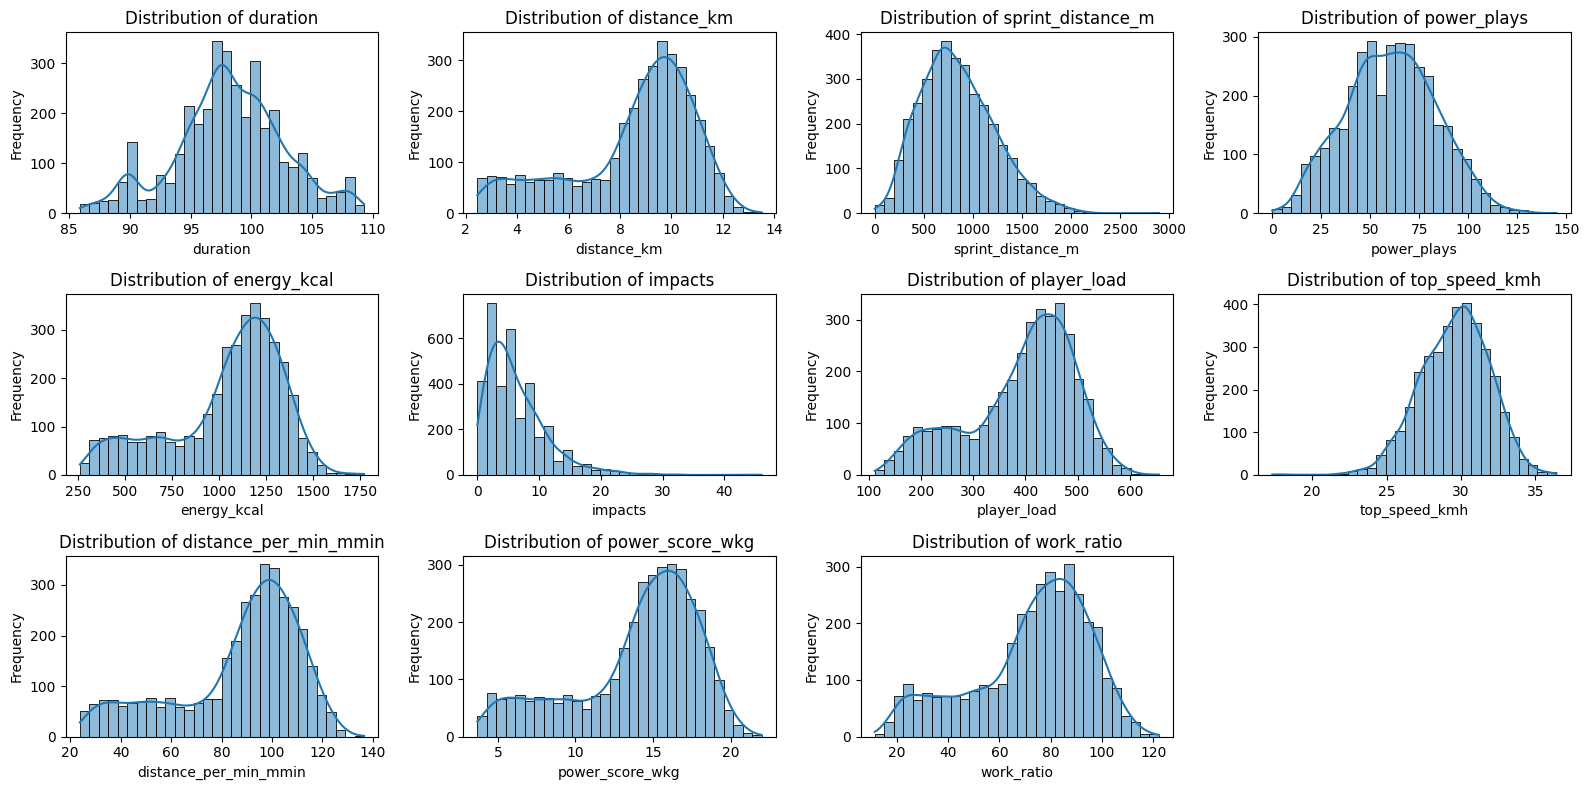

In [38]:
plot_numerical_distributions(match_df)

In [123]:
describe_numeric_columns(match_df)

,count,mean,std,min,median,max
duration,3592.0,98.203234,4.499897,85.883333,98.016667,109.300000
distance_km,3592.0,8.538918,2.427604,2.455100,9.208750,13.499000
sprint_distance_m,3592.0,847.455366,379.359197,1.519000,806.497000,2894.443000
power_plays,3592.0,60.511136,23.016500,0.000000,60.000000,145.000000
energy_kcal,3592.0,1044.079438,300.905062,261.662000,1124.255350,1771.047900
impacts,3592.0,6.287584,4.873845,0.000000,5.000000,46.000000
player_load,3592.0,392.415683,102.628830,111.517500,415.726600,655.960600
top_speed_kmh,3592.0,29.580822,2.314279,17.312100,29.736200,36.416300
distance_per_min_mmin,3592.0,87.017038,24.646851,23.832803,94.034394,136.524291
power_score_wkg,3592.0,14.000183,4.016899,3.674400,15.017850,21.988900


In [125]:
match_df['max_acceleration_mss'].describe()

count    3592.000000
mean        5.852622
std         0.634003
min         3.979800
25%         5.458400
50%         5.789900
75%         6.160000
max        10.000000
Name: max_acceleration_mss, dtype: float64

In [128]:

match_df.to_csv('UPL25_matches1.csv',index=False)